# Excercise 2a: Exploratory Data Analysis

In [10]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
X_train = pd.read_csv("ex2_train.csv")
y_train = pd.read_csv("ex2_class_train.csv")
data = X_train.copy()
data['Survived'] = y_train

In [12]:
data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,"Partner, Mr. Austen",male,45.5,0,0,28.5000,S,0
1,2,"Berriman, Mr. William John",male,23.0,0,0,13.0000,S,0
2,3,"Tikkanen, Mr. Juho",male,32.0,0,0,7.9250,S,0
3,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,7.8542,S,0
4,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,31.2750,S,0


This is a widely used dataset that contains information on the passengers who were aboard the Titanic when it sank on its maiden voyage in 1912. We will use it for a supervised learning exercise (ex2b) to predict whether a passenger can survive based on his or her attributes. Before constructing the classifier, you need to do some guided exploratory data analysis in ex2a.

The column meanings are: 
* Survived: Survival status (0 = No, 1 = Yes).
* Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd).
* Name: Name of the passenger.
* Sex: Gender of the passenger (male/female).
* Age: Age of the passenger in years.
* SibSp: Number of siblings/spouses aboard the Titanic.
* Parch: Number of parents/children aboard the Titanic.
* Fare: Passenger fare.
* Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

**TODO: Please answer the following questions by using suitable analysis tools, e.g. statistics or visualizations.** To pass the exercise, you need to correctly answer three or more of Questions 1 to 5. A correct answer includes a correct statement and the analysis result that support the statement.

# Example Question: Is gender related to survival rate?

Answer: Yes, females had a higher survival rate.

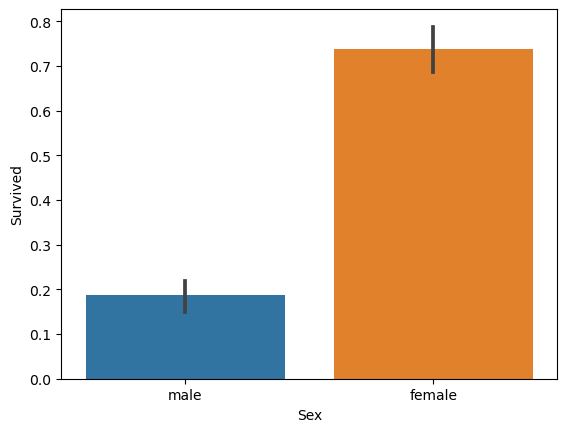

In [13]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Sex', y='Survived', data=data)
plt.show()

# Question 1: Did first-class passengers survive more?

Answer: Yes, first-class passengers had a higher survival rate than the other passengers.

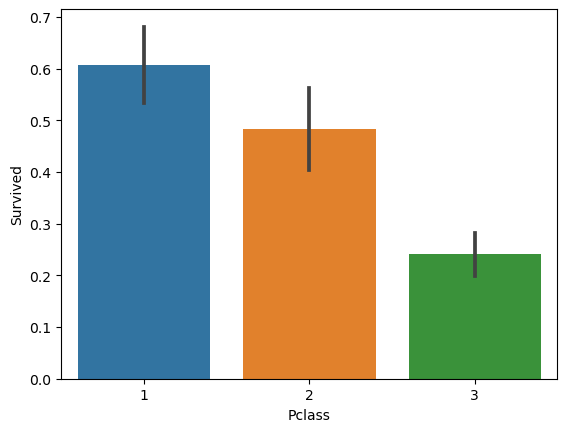

In [14]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Pclass', y='Survived', data=data)
plt.show()

# Question 2: Is survival related to Embarked?

Answer: Yes, that seems to be the same, but it is probably due to the different distributions of first-class passengers and female passengers (who have higher survival rate) in the different ports. For instance: the C port is the one with the highest survival rate because it had a lot of first-class passengers.

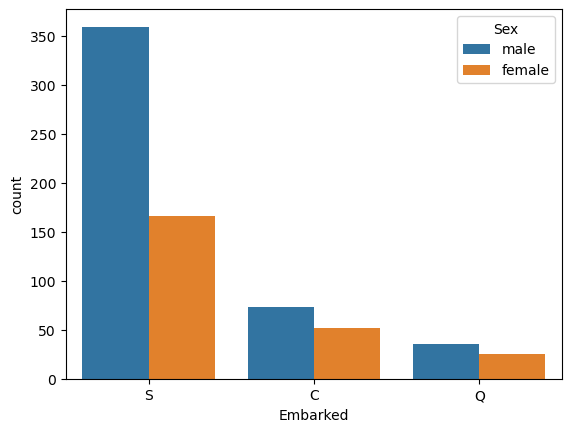

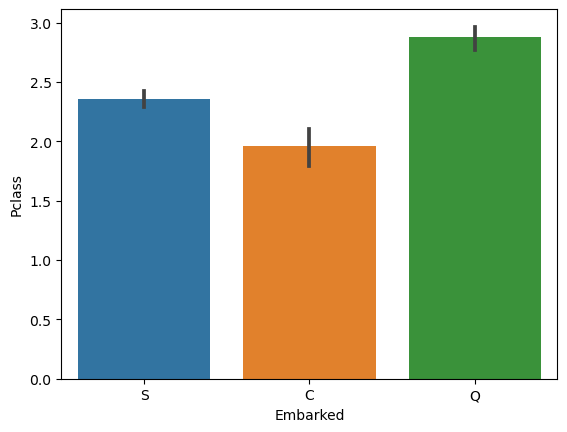

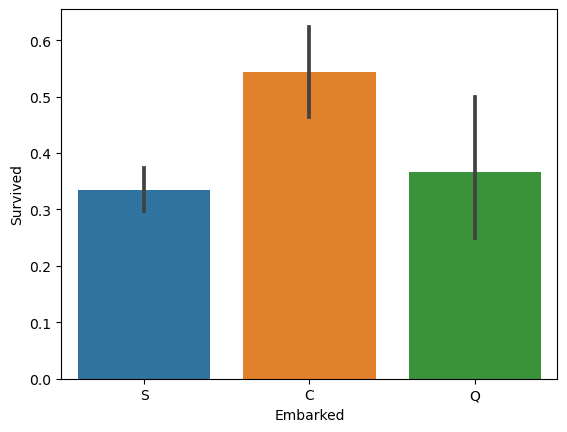

In [30]:
# Show the relevant statistics or visualization(s) to support your answer
sns.countplot(x='Embarked', hue='Sex', data=data)
plt.show()

sns.barplot(x='Embarked', y='Pclass', data=data)
plt.show()

sns.barplot(x='Embarked', y='Survived', data=data)
plt.show()

# Question 3: How is age related to survival?

Answer: Children (age 0-10) seem to have been more likely to survive if compared to the rest to the population. Young people (11-30) seems to have been the more likely age group to die. Older people (31-80) seems to have had better survival odds, but they were still more likely to die than to survive.

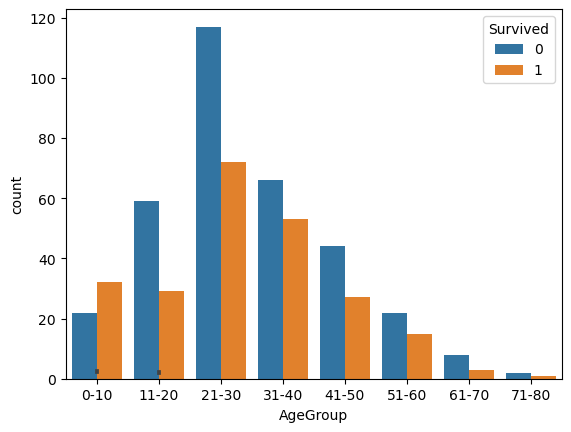

In [37]:
# Show the relevant statistics or visualization(s) to support your answersns.barplot(x='Embarked', y='Pclass', data=data)
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80],
    labels=['0-10', '11-20', '21-30', '31-40',
            '41-50', '51-60', '61-70', '71-80']
)

sns.barplot(x='Embarked', y='Pclass', data=data)

sns.countplot(
    x='AgeGroup',
    hue='Survived',
    data=data
)

plt.show()

# Question 4: Does family size somehow affect the survival rate?

Answer: Family size seems to be a positive effect on survival rate with a maximum value reached at 3 relatives present on the boat. After that (from 4 relatives onwards), it is possible to see a meaningful decrease and then a little bit of an increase at 6 relatives.

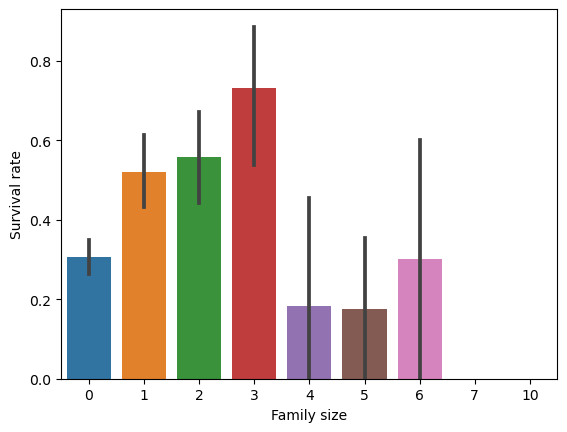

In [38]:
data['FamilySize'] = data['SibSp'] + data['Parch']

sns.barplot(x='FamilySize', y='Survived', data=data)

plt.xlabel('Family size')
plt.ylabel('Survival rate')
plt.show()

# Question 5: Some passengers with certain titles seemed to have more chance to survive. Is that true?

Answer: Yes, that seems to be true but it is important to note that this data is influenced by the fact that some titles are a lot more common that others (for instance we have a single countess and 419 misters). Also, the influence of social class and sex is also strong here (for instance, the countess is both a woman and a first-class passenger, so she has an increase rate of survival).

Mr          419
Miss        143
Mrs          96
Master       33
Rev           5
Dr            5
Major         2
Col           2
Mlle          2
Capt          1
Mme           1
Ms            1
Countess      1
Lady          1
Name: Title, dtype: int64


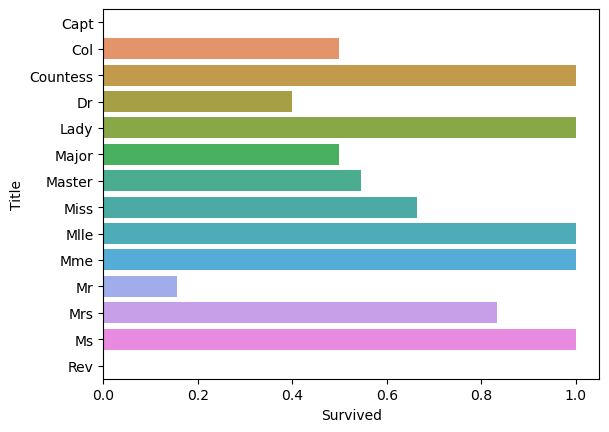

In [48]:
# Show the relevant statistics or visualization(s) to support your answer

# Extract titles
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# See the count of each title
print(data['Title'].value_counts())

# Find the average survival rate (mean) for each title
title_survival = data.groupby('Title')['Survived'].mean().reset_index()

sns.barplot(x='Survived', y='Title', data=title_survival)

plt.show()